In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read in usable cluster info
all = pd.read_csv('usable_cluster_fraction_all_cancers.csv')
tiss = pd.read_csv('usable_cluster_fraction_by_tissue.csv')

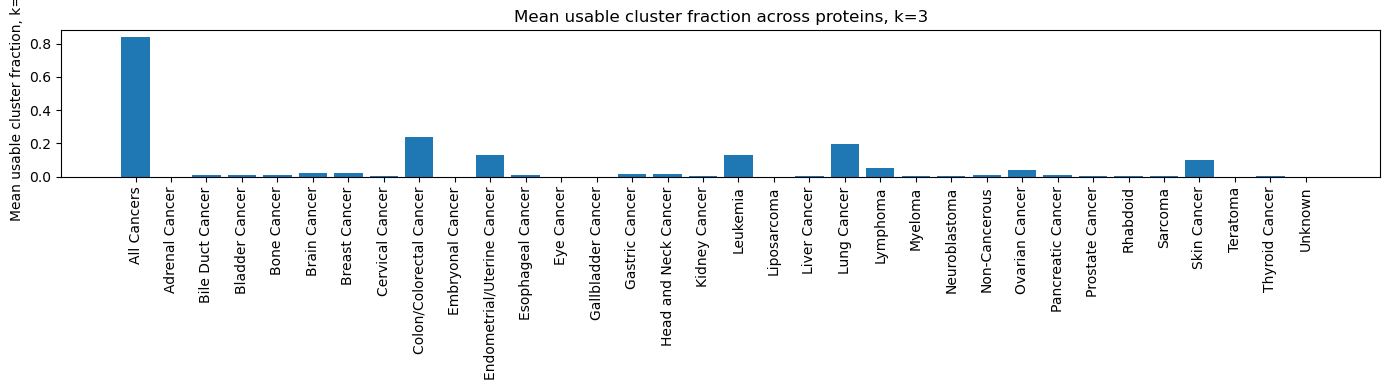

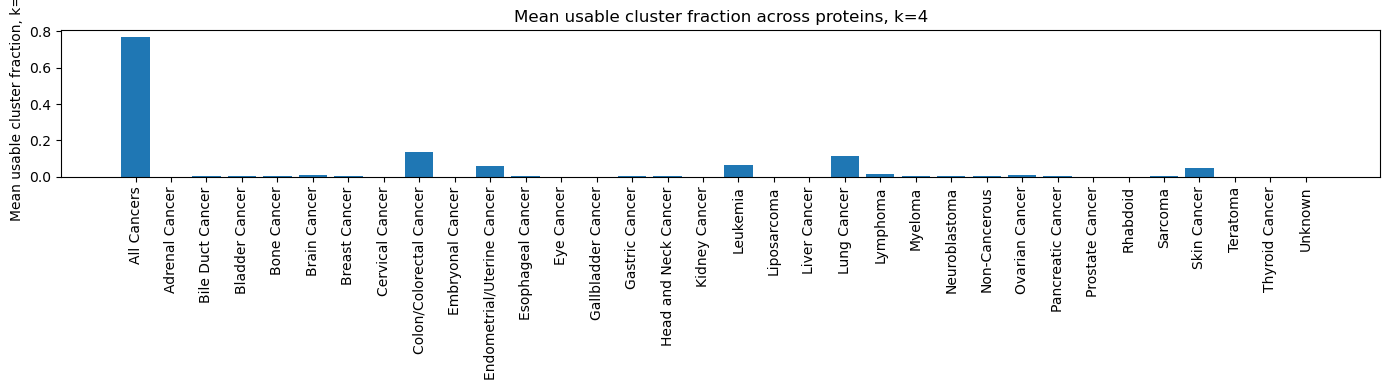

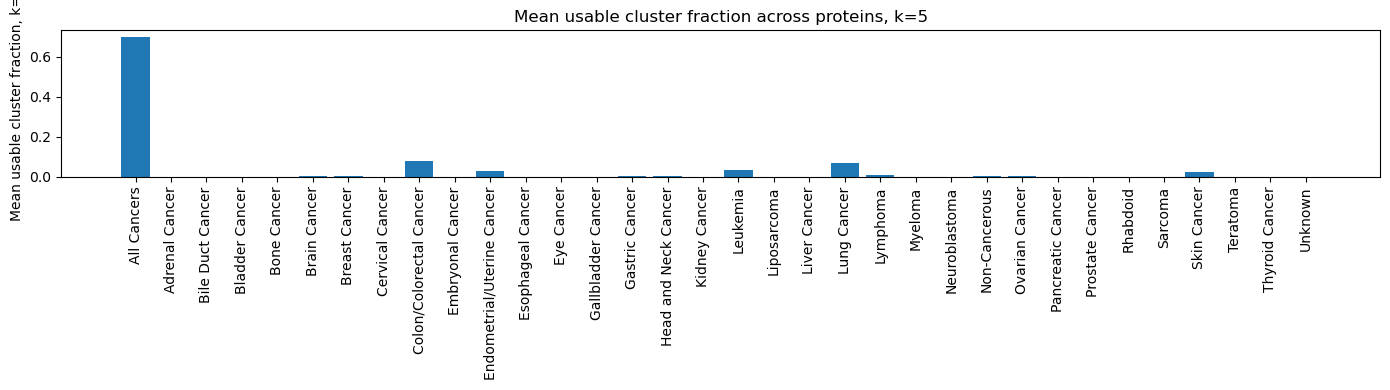

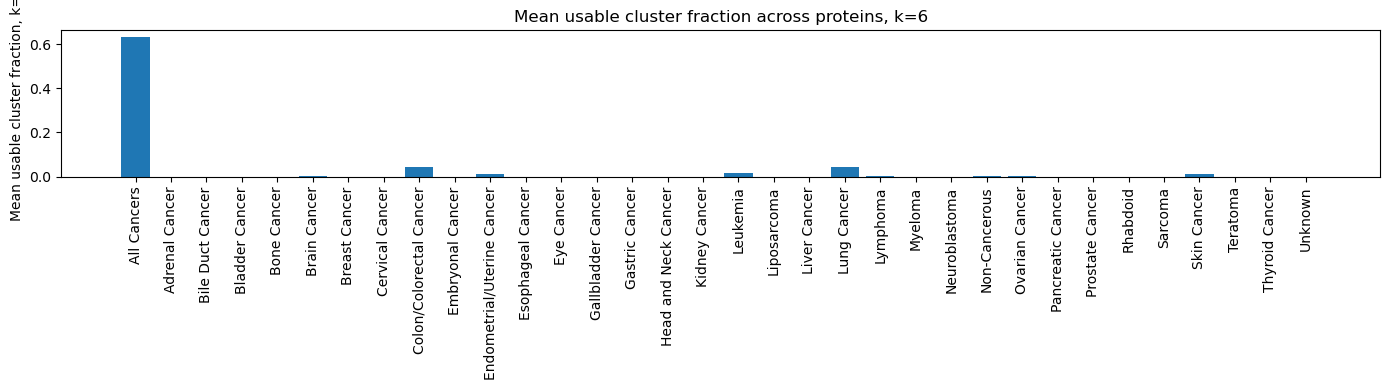

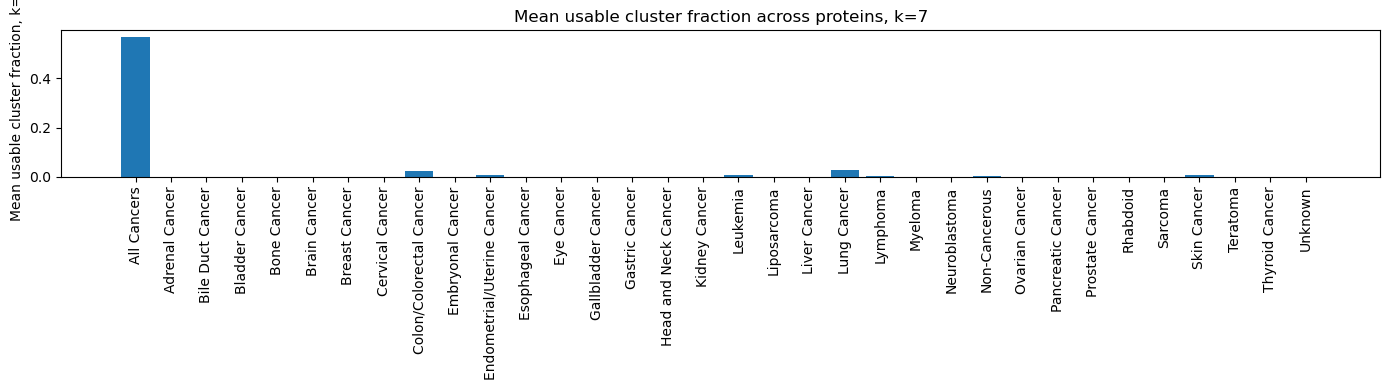

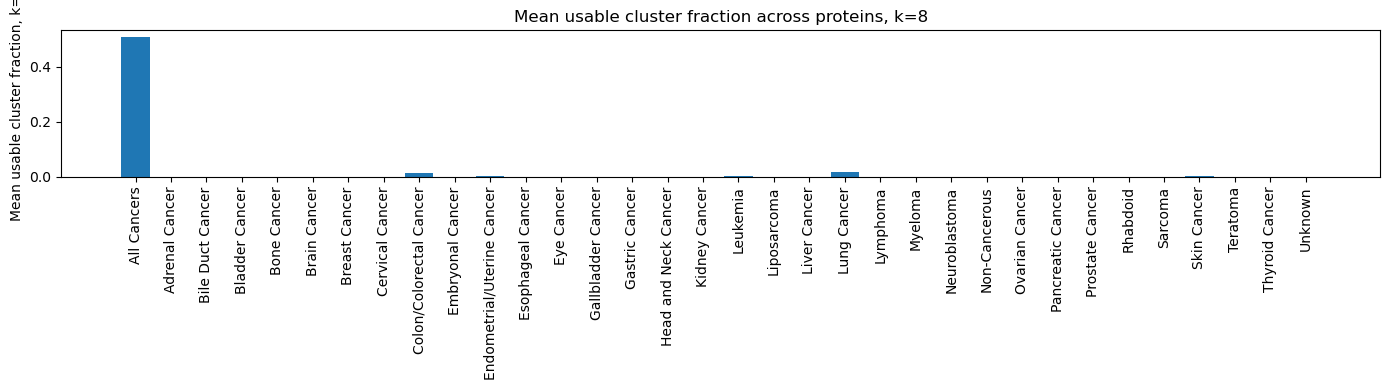

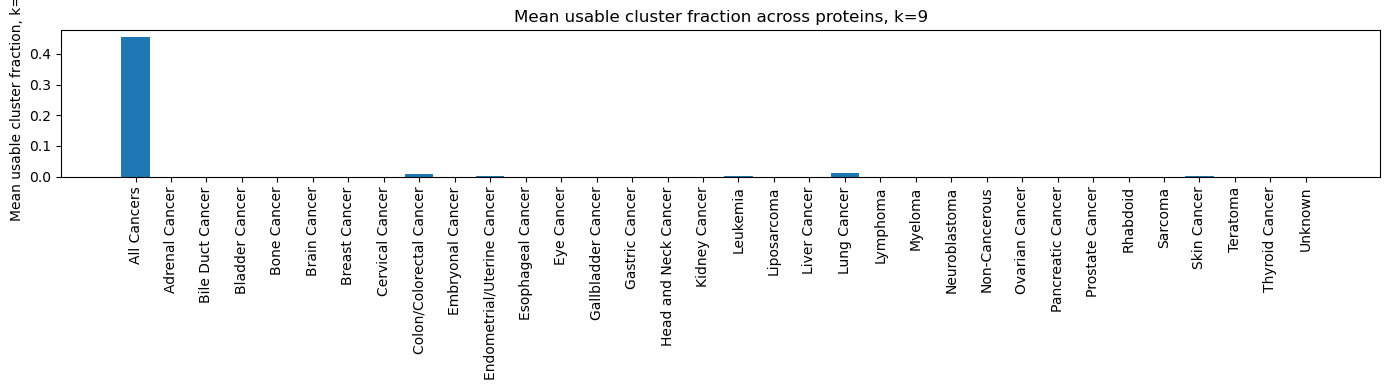

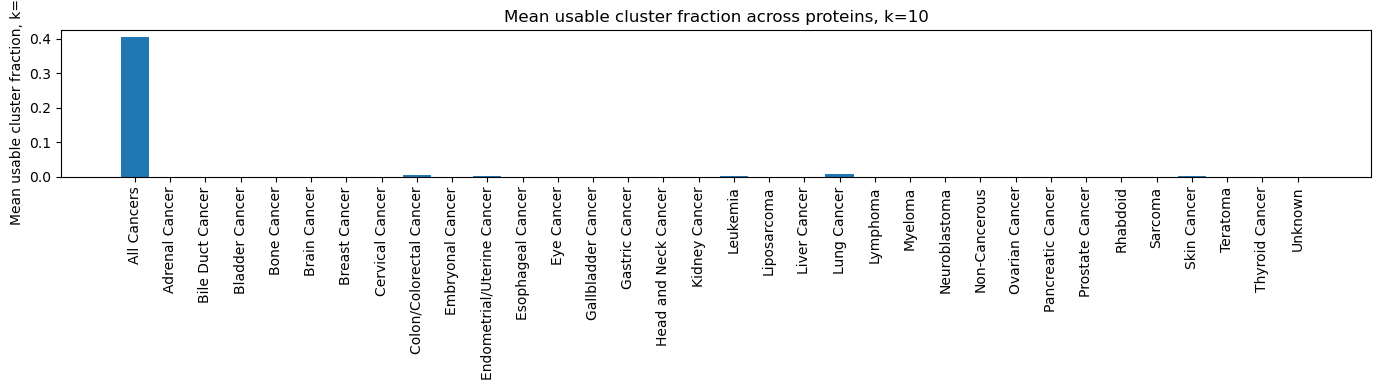

In [3]:
# Try a range of minimum cell lines
k_values = range(3, 11)

# Combine
plot_df = pd.concat([all, tiss], ignore_index=True)

# Make All Cancers appear first
order = ["All Cancers"] + sorted(
    [x for x in plot_df["primary_disease"].dropna().unique() if x != "All Cancers"]
)

for k in k_values:
    col = f"usable_cluster_fraction_k{k}"

    summary = (
        plot_df
        .groupby("primary_disease", as_index=False)[col]
        .mean()
    )

    summary["primary_disease"] = pd.Categorical(
        summary["primary_disease"],
        categories=order,
        ordered=True
    )

    summary = summary.sort_values("primary_disease")

    plt.figure(figsize=(14, 4))
    plt.bar(summary["primary_disease"], summary[col])

    plt.xticks(rotation=90)
    plt.ylabel(f"Mean usable cluster fraction, k={k}")
    plt.xlabel("")
    plt.title(f"Mean usable cluster fraction across proteins, k={k}")

    plt.tight_layout()
    plt.show()